# Разработка улучшенной модели прогнозирования спроса на велосипеды для компании BikeSouth

Разработал: Линюхин Илья

Дата: 01.10.2026

Целью проекта является улучшение линейной модели прогнозирования спроса на аренду велосипедов для компании BikeSouth. Необходимо разработать пайплайны для моделей kNN и дерева решений. Для данной задачей регрессии выбрана целевая метрика RMSE

От заказчика были получены датасеты для тренировки и тестирования моделей - `ds_s14_train_data.csv` и `ds_s14_train_data.csv` соответсвенно. 

Назначение признаков:
- Temperature - Температура воздуха в градусах Цельсия
- Humidity - Относительная влажность воздуха
- Windspeed - Скорость ветра
- Visibility - Видимость (в десятках метров)
- Dew Point Temperature - Точка росы
- Solar Radiation - Солнечная радиация
- Rainfall - Количество осадков
- Snowfall - Количество снега
- Seasons - Времена года
- Holiday - Был ли в этот день выходной/праздничный день
- Functioning Day - Были ли велосипеды арендованы в рабочее время
- Time_Period - Обозначение временного периода
- Rented Bike Count - кол-во велосипедов, арендованных за промежуток времени (целевая переменная)

---

Импортируем необходимые библиотеки:

In [1]:
!pip install optuna

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import joblib
import seaborn as sns
from phik import phik_matrix

from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, OrdinalEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold,train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

RANDOM_STATE=42

In [3]:
!pip freeze > requirements.txt

Загрузим датасеты:

In [4]:
try:
    df_train = pd.read_csv('data/ds_s14_train_data.csv')
    df_test = pd.read_csv('data/ds_s14_test_data.csv')
    print('Датасеты загружены успешно!')
except:
    df_train = pd.read_csv('ds_s14_train_data.csv')
    df_test = pd.read_csv('ds_s14_test_data.csv')
    print('Датасеты загружены успешно!')

Датасеты загружены успешно!


Проверим загрузку датасетов:

In [5]:
df_train.sample()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
4949,-2.2,42.0,1.3,1646.0,-13.4,0.61,0.0,NaN,Winter,No Holiday,Yes,False,False,False,False,273


In [6]:
df_test.sample()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
909,-10.1,38.0,2.3,2000.0,-21.7,0.0,0.0,0.0,Winter,No Holiday,Yes,False,False,True,False,262


Строки выводятся без проблем.

# **Часть 1: Базовая модель**

Загрузим модель которую нам предоставила компания BikeSouth:

In [7]:
try:
    loaded_model = joblib.load('models/baseline_linear_regression_pipeline.joblib')
    print('Модель успешно загружена!')
except:
    loaded_model = joblib.load('baseline_linear_regression_pipeline.joblib')
    print('Модель успешно загружена!')

Модель успешно загружена!


Сразу посмотрим на состав загруженного пайплайна:

In [8]:
loaded_model.named_steps.keys()

dict_keys(['preprocessor', 'model'])

Посмотрим на веса модели:

In [9]:
baseline_weights = loaded_model.named_steps['model'].coef_

baseline_features = loaded_model.named_steps['preprocessor'].get_feature_names_out()

baseline_model_feature_weights = pd.DataFrame({
    'feature':baseline_features,
    'weight':baseline_weights,
    'abs_weight': abs(baseline_weights)
})
baseline_model_feature_weights.sort_values('abs_weight', ascending=False)

,feature,weight,abs_weight
16,time__time_period_evening,518.384163,518.384163
15,cat__functioning_day_Yes,468.950829,468.950829
14,cat__functioning_day_No,-468.950829,468.950829
17,time__time_period_late_evening,413.039584,413.039584
0,num__temperature,315.570571,315.570571
18,time__time_period_morning,241.268021,241.268021
11,cat__seasons_Winter,-190.566264,190.566264
8,cat__seasons_Autumn,164.011222,164.011222
1,num__humidity,-126.362276,126.362276
19,time__time_period_night,-116.935350,116.935350


Обратим внимание что все названия признаков приведены к Snake Case. Напишим функцию, которая приводит названия столбцов к snake_case:

In [10]:
def to_snake_case(data):
    df_renamed = data.copy()
    renamed_features = {}
    for col in data.columns:
        renamed_col = col.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('%', '').replace('/', '')
        renamed_features[col] = renamed_col
    df_renamed = df_renamed.rename(columns=renamed_features)
    return df_renamed

Приведем исходные датасеты к Snake Case:

In [11]:
df_train = to_snake_case(df_train)
df_test = to_snake_case(df_test)

print(f'Названия признаков train: {df_train.columns}')
print('')
print(f'Названия признаков test: {df_test.columns}')

Названия признаков train: Index(['temperature', 'humidity', 'wind_speed_ms', 'visibility_10m',
       'dew_point_temperature', 'solar_radiation_mjm2', 'rainfallmm',
       'snowfall_cm', 'seasons', 'holiday', 'functioning_day',
       'time_period_evening', 'time_period_late_evening',
       'time_period_morning', 'time_period_night', 'rented_bike_count'],
      dtype='object')

Названия признаков test: Index(['temperature', 'humidity', 'wind_speed_ms', 'visibility_10m',
       'dew_point_temperature', 'solar_radiation_mjm2', 'rainfallmm',
       'snowfall_cm', 'seasons', 'holiday', 'functioning_day',
       'time_period_evening', 'time_period_late_evening',
       'time_period_morning', 'time_period_night', 'rented_bike_count'],
      dtype='object')


Разделим новые датасеты на матрицу признаков и целевую переменную:

In [12]:
X_train_baseline = df_train.drop(columns='rented_bike_count')
y_train_baseline = df_train['rented_bike_count']

X_test_baseline = df_test.drop(columns='rented_bike_count')
y_test_baseline = df_test['rented_bike_count']

Составим таблицу метрик для baseline модели. В качестве метрик будем использовать RMSE, MAE и R2:

In [13]:
y_train_pred_baseline = loaded_model.predict(X_train_baseline)
y_test_pred_baseline = loaded_model.predict(X_test_baseline)

baseline_results = pd.DataFrame({
    'Data': ['Train', 'Test'],
    'RMSE': [np.sqrt(mean_squared_error(y_train_baseline, y_train_pred_baseline)),
            np.sqrt(mean_squared_error(y_test_baseline, y_test_pred_baseline))],
    'MAE': [mean_absolute_error(y_train_baseline, y_train_pred_baseline),
           mean_absolute_error(y_test_baseline, y_test_pred_baseline)],
    'R2': [r2_score(y_train_baseline, y_train_pred_baseline),
          r2_score(y_test_baseline, y_test_pred_baseline)]
})

baseline_results

,Data,RMSE,MAE,R2
0,Train,412.499623,309.152519,0.592596
1,Test,411.454458,312.531298,0.586293


Мы получили метрики baseline модели. В дальнейшем данные метрики будут использованы для сравнения улучшенных моделей. Так же в данном разделе была разработана функция to_snake_case, которая приводит названия столбцов к snake_case

Т.к. baseline модель - линейная, мы можем выделить по весам модели наиболее влиятельные признаки:
- `Time_Period` - временной период
- `Functioning Day` - Были ли велосипеды арендованы в рабочее время
- `Temperature` - Температура воздуха в градусах Цельсия

# **Часть 2: Улучшение модели — KNN и Decision Tree**

## EDA

Начнем EDA с тренировочного датасета. Выведем общую информацию о нем:

In [14]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   temperature               7008 non-null   float64
 1   humidity                  6758 non-null   float64
 2   wind_speed_ms             6798 non-null   float64
 3   visibility_10m            6749 non-null   float64
 4   dew_point_temperature     7008 non-null   float64
 5   solar_radiation_mjm2      6798 non-null   float64
 6   rainfallmm                6746 non-null   float64
 7   snowfall_cm               6745 non-null   float64
 8   seasons                   7008 non-null   object 
 9   holiday                   7008 non-null   object 
 10  functioning_day           7008 non-null   object 
 11  time_period_evening       7008 non-null   bool   
 12  time_period_late_evening  7008 non-null   bool   
 13  time_period_morning       7008 non-null   bool   
 14  time_per

Датасет состоит из 7008 строк и 16 столбцов. Выведем первые строки датасета:

In [15]:
df_train.head()

,temperature,humidity,wind_speed_ms,visibility_10m,dew_point_temperature,solar_radiation_mjm2,rainfallmm,snowfall_cm,seasons,holiday,functioning_day,time_period_evening,time_period_late_evening,time_period_morning,time_period_night,rented_bike_count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


Пояснение к признакам:
- `Temperature` - Температура воздуха в градусах Цельсия
- `Humidity` - Относительная влажность воздуха
- `Windspeed` - Скорость ветра
- `Dew Point Temperature` - Точка росы
- `Solar Radiation` - Солнечная радиация
- `Rainfall` - Количество осадков
- `Snowfall` - Количество снега
- `Seasons` - Времена года
- `Holiday` - Был ли в этот день выходной или праздничный день
- `Functioning Day` - Были ли велосипеды арендованы в рабочее время
- `Time_Period` - Каждая запись в датасете относится к одному из пяти временных периодов: `Night`, `Morning`, `Daytime`, `Evening`, `Late Evening`
- `Rented Bike Count` - Целевая переменная. Отражает кол-во велосипедов, которые были арендованны за временной промежуток

### Целевая переменная Rented Bike Count

Посмотрим сводку по целевой переменной и посмотрим на распределение:

In [16]:
df_train_orig = df_train.copy()

In [17]:
df_train['rented_bike_count'].describe()

count    7008.000000
mean      705.606022
std       646.311790
min         0.000000
25%       190.750000
50%       504.500000
75%      1070.000000
max      3556.000000
Name: rented_bike_count, dtype: float64

Проверим пропуски:

In [18]:
print('Кол-во пропусков:', df_train['rented_bike_count'].isna().sum())

Кол-во пропусков: 0


Построим гистограмму и посмотрим на распределение целевой переменной:

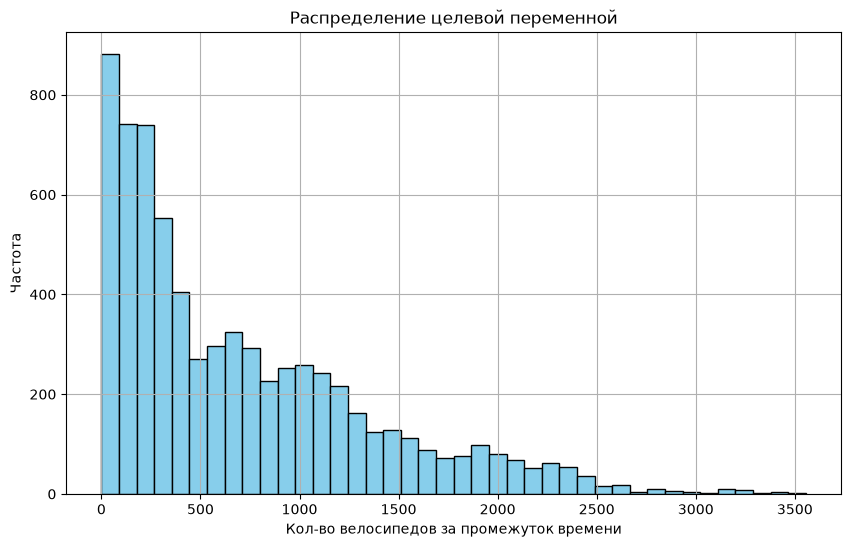

In [19]:
plt.figure(figsize=(10,6))
plt.hist(df_train['rented_bike_count'],
        bins=40,
        color='skyblue',
        edgecolor='black')
plt.grid()
plt.title('Распределение целевой переменной')
plt.xlabel('Кол-во велосипедов за промежуток времени')
plt.ylabel('Частота')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21696\3345266257.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_train['rented_bike_count'],


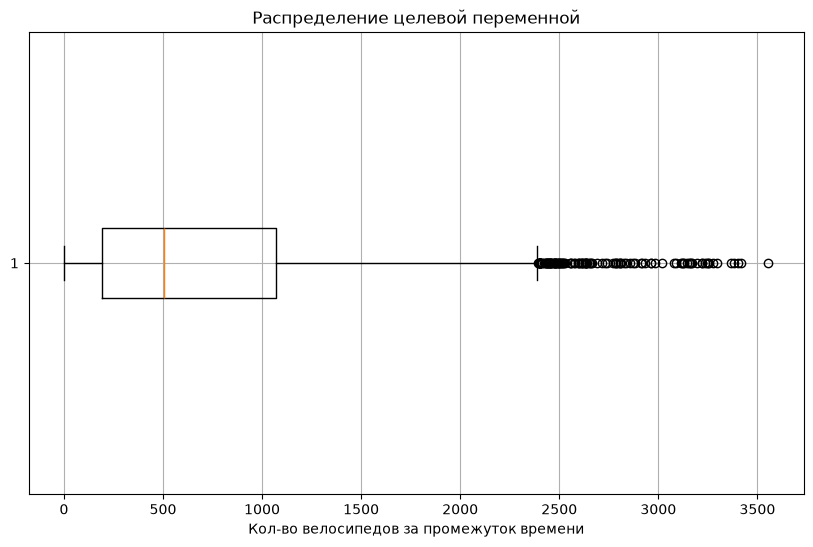

In [20]:
plt.figure(figsize=(10,6))
plt.boxplot(df_train['rented_bike_count'],
           vert=False)
plt.grid()
plt.title('Распределение целевой переменной')
plt.xlabel('Кол-во велосипедов за промежуток времени')
plt.show()

В целевой переменной наблюдается сильное смещение, что может говорить о наличии выбросов. На графиках видно что существуют значения более 2500. Изучим такие строчки:

In [21]:
print(f'Доля строк со значением выше 2500: {df_train[df_train["rented_bike_count"] > 2500].shape[0] / df_train.shape[0] * 100}')

Доля строк со значением выше 2500: 1.1130136986301369


In [22]:
df_train[df_train["rented_bike_count"] > 2500]

,temperature,humidity,wind_speed_ms,visibility_10m,dew_point_temperature,solar_radiation_mjm2,rainfallmm,snowfall_cm,seasons,holiday,functioning_day,time_period_evening,time_period_late_evening,time_period_morning,time_period_night,rented_bike_count
36,25.9,52.0,2.1,2000.0,15.2,0.57,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,3196
206,28.2,64.0,2.8,1978.0,20.7,0.50,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,2637
557,21.2,52.0,3.6,1856.0,10.9,0.55,0.0,0.0,Spring,No Holiday,Yes,True,False,False,False,2650
892,27.5,47.0,2.5,1113.0,15.1,0.43,0.0,0.0,Spring,No Holiday,Yes,True,False,False,False,2915
934,33.0,51.0,2.4,1566.0,21.5,1.23,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,2640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6558,28.1,60.0,1.9,959.0,19.5,1.05,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,3113
6602,23.3,68.0,3.6,895.0,17.0,0.11,0.0,0.0,Summer,No Holiday,Yes,False,True,False,False,2519
6729,28.4,75.0,NaN,1564.0,23.5,0.52,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,2931
6838,21.2,NaN,3.8,1927.0,3.8,0.94,0.0,0.0,Spring,No Holiday,Yes,True,False,False,False,2807


Всего существует 78 строк с выбросами. Считаю что данные выбросы могут нести в себе ценность т.к. они могут указывать на дни с аномально высоким спросом.

### Числовые признаки

Изучим следующие числовые признаки:
- `Temperature`
- `Humidity`
- `Windspeed`
- `Visibility`
- `Dew Point Temperature`
- `Solar Radiation`
- `Rainfall`
- `Snowfall`

In [23]:
num_cols = ['temperature', 'humidity', 'wind_speed_ms', 'visibility_10m', 'dew_point_temperature', 'solar_radiation_mjm2',
           'rainfallmm', 'snowfall_cm']

def num_col_describe(col, binsize):
    print(f'Сводка по столбцу {col}')
    print('')
    display(df_train[col].describe())
    print('')
    print(f'Кол-во пропусков в столбце {col}: {df_train[col].isna().sum()}')
    print(f'Доля пропусков в столбце {col}: {round(df_train[col].isna().sum() / df_train.shape[0], 2)}')
    plt.figure(figsize=(10,6))
    plt.hist(
        df_train[col],
        color='skyblue',
        edgecolor='black',
        alpha=0.7,
        bins=binsize
    )
    plt.grid()
    plt.xlabel(f'Значения {col}')
    plt.ylabel('Частота')
    plt.title(f'Распределение значений признака {col}')
    plt.show()
    print('=' * 50)

Пройдемся по каждому признаку по порядку:

#### Temperature

Сводка по столбцу temperature



count    7008.000000
mean       12.812914
std        11.924688
min       -17.500000
25%         3.300000
50%        13.500000
75%        22.400000
max        39.400000
Name: temperature, dtype: float64


Кол-во пропусков в столбце temperature: 0
Доля пропусков в столбце temperature: 0.0


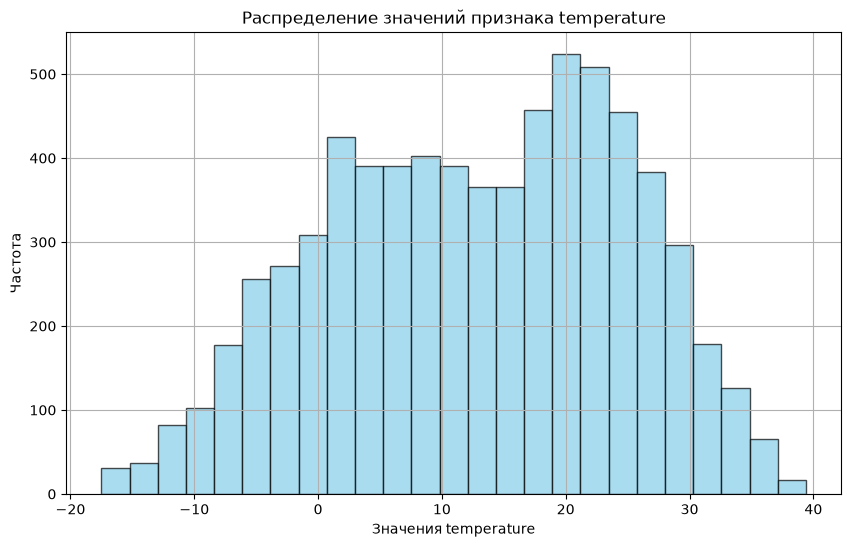

In [24]:
num_col_describe('temperature', 25)

Признак означает температуру воздуха и имеет нормальное симметричное распределение. Пропуски отсутствуют. Никаких действий с данным признаком кроме масштабирования не требуется.

#### Humidity

Сводка по столбцу humidity



count    6758.000000
mean       58.200503
std        20.340317
min         0.000000
25%        42.000000
50%        57.000000
75%        74.000000
max        98.000000
Name: humidity, dtype: float64


Кол-во пропусков в столбце humidity: 250
Доля пропусков в столбце humidity: 0.04


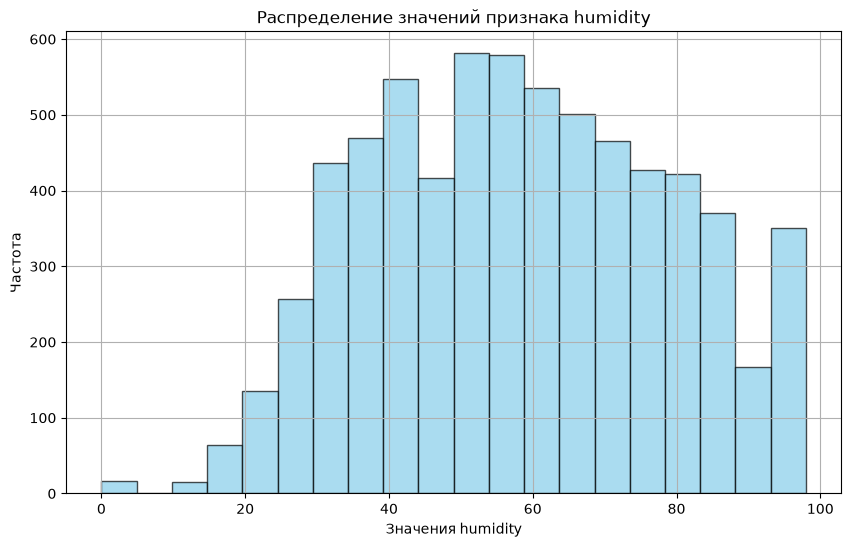

In [25]:
num_col_describe('humidity', 20)

Отражает относительную влажность воздуха. Распределение симметричное, выбросы отсутствуют. Присутствуют пропуски. Посмотрим на строки с пропусками:

In [26]:
df_train[df_train['humidity'].isna()]

,temperature,humidity,wind_speed_ms,visibility_10m,dew_point_temperature,solar_radiation_mjm2,rainfallmm,snowfall_cm,seasons,holiday,functioning_day,time_period_evening,time_period_late_evening,time_period_morning,time_period_night,rented_bike_count
23,23.8,NaN,0.6,2000.0,17.2,0.00,0.0,0.0,Autumn,No Holiday,Yes,False,True,False,False,2000
95,28.9,NaN,2.0,1975.0,14.6,2.50,0.0,0.0,Summer,No Holiday,Yes,False,False,False,False,1070
103,-10.3,NaN,2.0,2000.0,-19.2,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,77
115,15.5,NaN,1.7,2000.0,5.6,0.70,0.0,0.0,Spring,No Holiday,Yes,True,False,False,False,1118
131,6.2,NaN,0.6,1584.0,-1.2,0.00,0.0,NaN,Autumn,No Holiday,Yes,False,False,False,True,327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6891,24.3,NaN,1.8,1931.0,17.0,0.59,0.0,0.0,Summer,No Holiday,Yes,False,False,False,False,782
6921,-15.3,NaN,0.8,1963.0,-25.0,0.00,0.0,0.3,Winter,No Holiday,Yes,False,False,False,True,41
6923,33.2,NaN,2.6,1289.0,24.0,2.37,0.0,0.0,Summer,No Holiday,Yes,False,False,False,False,613
6936,11.4,NaN,1.0,885.0,8.0,0.02,0.0,0.0,Spring,No Holiday,No,False,False,True,False,0


Т.к. распределение симметричное, а кол-во пропусков небольшое - пропуски буду заполнять медианой. 

#### WindSpeed

Сводка по столбцу wind_speed_ms



count    6798.000000
mean        1.725228
std         1.042956
min         0.000000
25%         0.900000
50%         1.500000
75%         2.300000
max         7.400000
Name: wind_speed_ms, dtype: float64


Кол-во пропусков в столбце wind_speed_ms: 210
Доля пропусков в столбце wind_speed_ms: 0.03


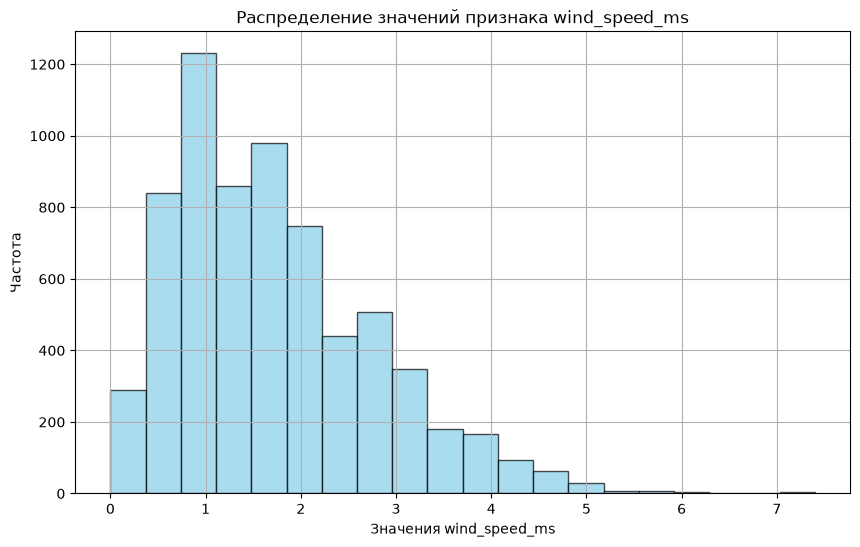

In [27]:
num_col_describe('wind_speed_ms', 20)

Распределение вытянуто вправо, но наличие выбросов характерно для скорости ветра. Редко, но бывают штормовые дни со скоростью ветра до 7 м/с. Такие выбросы в данных очень ценные, т.к. могут прогнозировать низкий спрос на велосипеды.

В признаке присутствуют 210 записей с пропусками. В препроцессоре заполним эти данные медианой.

#### Visibility

Сводка по столбцу visibility_10m



count    6749.000000
mean     1435.156764
std       607.291049
min        27.000000
25%       936.000000
50%      1691.000000
75%      2000.000000
max      2000.000000
Name: visibility_10m, dtype: float64


Кол-во пропусков в столбце visibility_10m: 259
Доля пропусков в столбце visibility_10m: 0.04


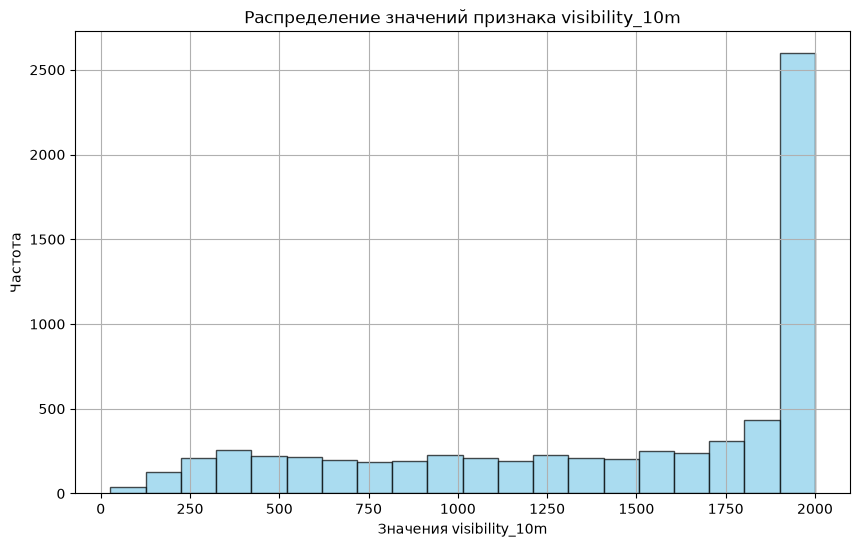

In [28]:
num_col_describe('visibility_10m', 20)

Признак отражает видимость в дестяках метрах. По гистограмме можно заметить что чаще всего видимость хорошая и составляет 20км. В данном признаке содержатся 259 строк с пропусками, которые можно будет заполнить медианой.

#### Dew Point Temperature

Сводка по столбцу dew_point_temperature



count    7008.000000
mean        4.021490
std        13.033377
min       -30.600000
25%        -4.700000
50%         5.000000
75%        14.800000
max        26.800000
Name: dew_point_temperature, dtype: float64


Кол-во пропусков в столбце dew_point_temperature: 0
Доля пропусков в столбце dew_point_temperature: 0.0


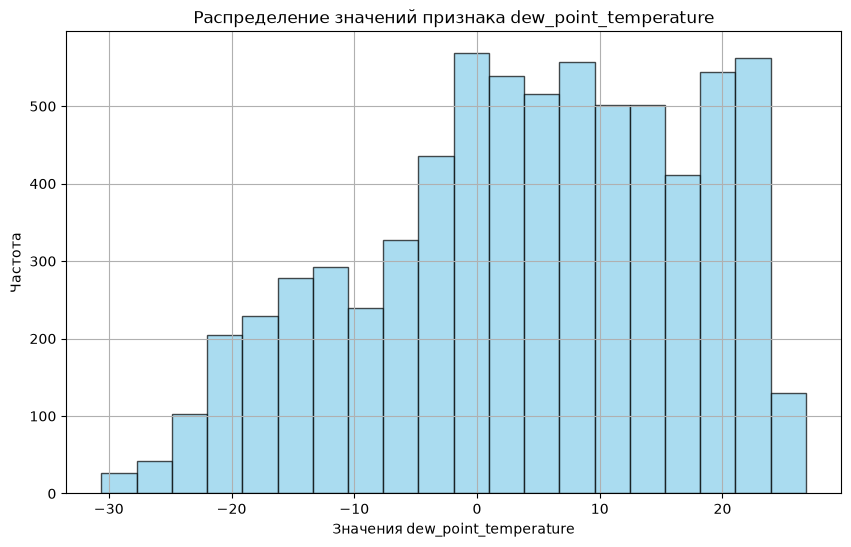

In [29]:
num_col_describe('dew_point_temperature', 20)

Признак отражает точку росы. Распределение - нормальное. Выбросы отсутствуют.

#### Solar Radiation

Сводка по столбцу solar_radiation_mjm2



count    6798.000000
mean        0.569885
std         0.866142
min         0.000000
25%         0.000000
50%         0.010000
75%         0.940000
max         3.520000
Name: solar_radiation_mjm2, dtype: float64


Кол-во пропусков в столбце solar_radiation_mjm2: 210
Доля пропусков в столбце solar_radiation_mjm2: 0.03


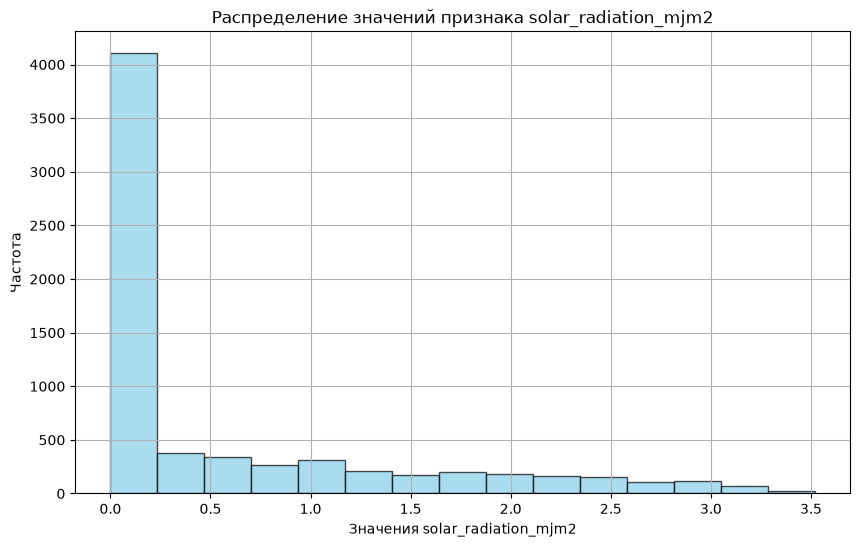

In [30]:
num_col_describe('solar_radiation_mjm2', 15)

Признак solar_radiation_mjm2 отражает значение солничной радиации. Расределение сильно смещенною Чаще всего значение данного признака находится около 0. Присутствуют 210 пропусков в данных. Заполним их медианой.

#### Rainfall

Сводка по столбцу rainfallmm



count    6746.000000
mean        0.146902
std         1.164118
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        35.000000
Name: rainfallmm, dtype: float64


Кол-во пропусков в столбце rainfallmm: 262
Доля пропусков в столбце rainfallmm: 0.04


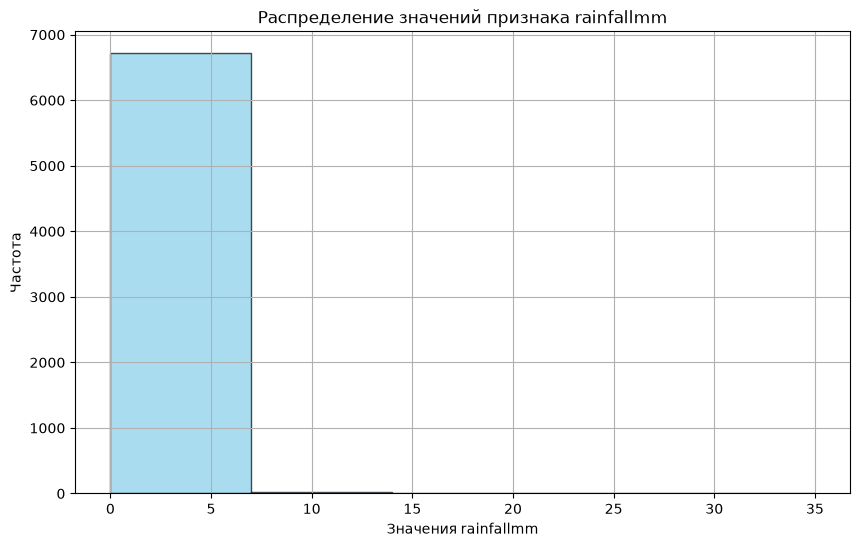

In [31]:
num_col_describe('rainfallmm', 5)

Признак rainfallmm показывает кол-во осадков в мм. Чаще всего осадки отсутствуют совсем. В признаке находится 262 признака. Т.к. осадки практически всегда отсутствуют - предлагаю запоолнить данные пропуски модой

#### Snowfall

Сводка по столбцу snowfall_cm



count    6745.000000
mean        0.074752
std         0.438189
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         8.800000
Name: snowfall_cm, dtype: float64


Кол-во пропусков в столбце snowfall_cm: 263
Доля пропусков в столбце snowfall_cm: 0.04


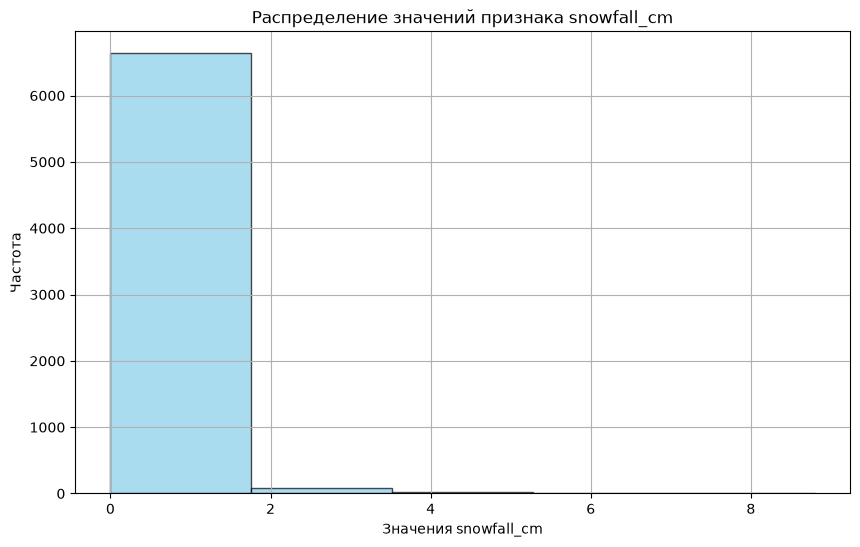

In [32]:
num_col_describe('snowfall_cm', 5)

Признак snowfall_cm показывает кол-во снега. Чаще всего снег отсутствует. По аналогии с rainfall предлагаю заполнить пропуски модой.

---

### Категориальные признаки

Рассмотрим категориальные признаки:
- `Seasons`
- `Holiday`
- `Functioning Day`
- `Time_Period`

In [33]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   temperature               7008 non-null   float64
 1   humidity                  6758 non-null   float64
 2   wind_speed_ms             6798 non-null   float64
 3   visibility_10m            6749 non-null   float64
 4   dew_point_temperature     7008 non-null   float64
 5   solar_radiation_mjm2      6798 non-null   float64
 6   rainfallmm                6746 non-null   float64
 7   snowfall_cm               6745 non-null   float64
 8   seasons                   7008 non-null   object 
 9   holiday                   7008 non-null   object 
 10  functioning_day           7008 non-null   object 
 11  time_period_evening       7008 non-null   bool   
 12  time_period_late_evening  7008 non-null   bool   
 13  time_period_morning       7008 non-null   bool   
 14  time_per

In [34]:
def cat_col_describe(col):
    print(f'Описание признака {col}')
    print('')
    print(f'Кол-во пропусков в столбце {col}: {df_train[col].isna().sum()}')
    print(f'Доля пропусков в столбце {col}: {round(df_train[col].isna().sum() / df_train.shape[0], 2)}')
    print('')
    plt.figure(figsize=(10,6))
    df_train[col].value_counts().plot(kind='bar',
                                      color='skyblue',
                                      edgecolor='black',
                                      alpha=0.7,
                                      rot=45,
                                      title=f'Распределение категорий {col}',
                                      xlabel='Название категории',
                                      ylabel='Частота')
    plt.grid()
    plt.show()

#### Seasons

Описание признака seasons

Кол-во пропусков в столбце seasons: 0
Доля пропусков в столбце seasons: 0.0



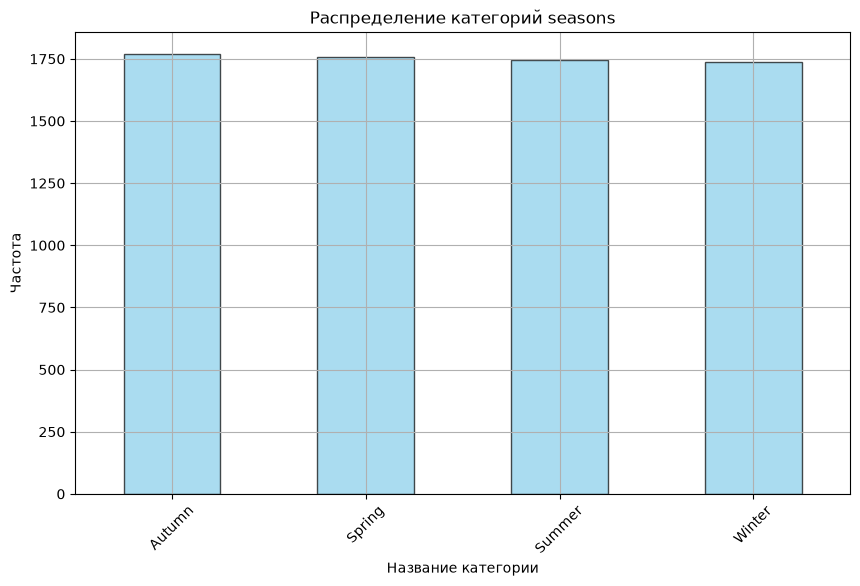

In [35]:
cat_col_describe('seasons')

Признак season содержит в себе информацию о времени года. Всего 4 категории, как и сезонов. Распределение о записях - нормальное. Пропуски отсутствуют.

#### Holiday

Описание признака holiday

Кол-во пропусков в столбце holiday: 0
Доля пропусков в столбце holiday: 0.0



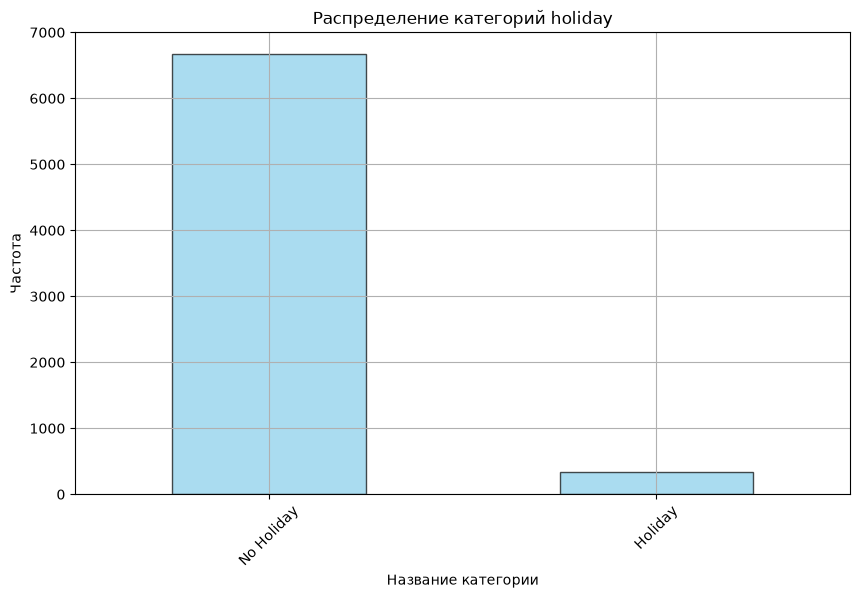

In [36]:
cat_col_describe('holiday')

Признак holiday отражает выходной/праздничный день записи. В контексте признака распределение нормальное. Обычные будние дни кратно превышают по количеству праздничные. Пропуски отсутствуют.

#### Functioning Day

Описание признака functioning_day

Кол-во пропусков в столбце functioning_day: 0
Доля пропусков в столбце functioning_day: 0.0



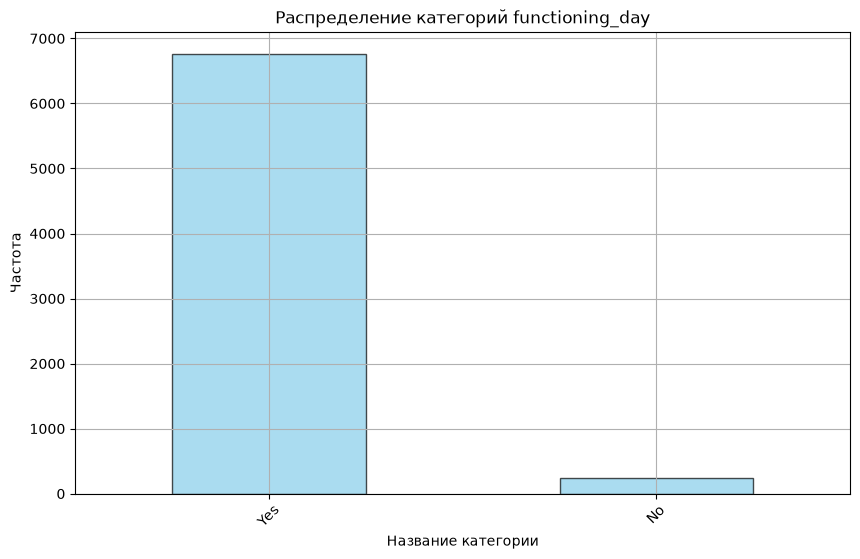

In [37]:
cat_col_describe('functioning_day')

Признак показывает работал ли прокат в момент записи, или был на тех обслуживании. Пропуски отсутсвуют.

#### Time_Period

Признак time_period закодирован с помощью OneHot. Такие признаки избавляют нас от необходимости кодирования в дальнейшем.

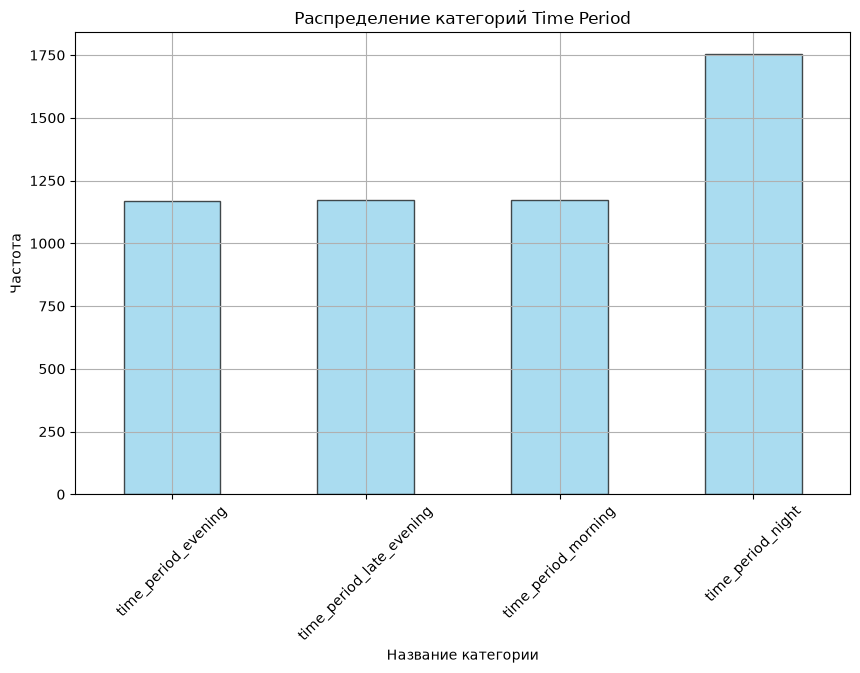

In [38]:
plt.figure(figsize=(10,6))
df_train[['time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night']].sum().plot(kind='bar',
                                                                                                                     color='skyblue',
                                                                                                                     edgecolor='black',
                                                                                                                     alpha=0.7,
                                                                                                                     rot=45,
                                                                                                                     title=f'Распределение категорий Time Period',
                                                                                                                     xlabel='Название категории',
ylabel='Частота')
plt.grid()
plt.show()

После построения столбчатой диаграммы мы можем видеть, что самая поплуярное время - с 00:00 по 05:59. Однако, если во всех признаках стоит False - автоматически считается daytime. Посмотрим сколько раз была запись в дневное время:

In [39]:
print('Кол-во записей с 10:00 по 15:59:', df_train.shape[0] - df_train[['time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night']].sum().sum())

Кол-во записей с 10:00 по 15:59: 1742


Таким образм мы можем сказать что аренда происходит в основном с 00:00 по 05:59 (вероятнее всего рано утром), а так же с 10:00 по 15:59

#### Дубликаты

Проверим датасет на полные дубликаты:

In [40]:
df_train.duplicated().sum()

np.int64(0)

Явные дубликаты отсутсвуют.

### Test Выборка:

Выведем информацию о тестовой выборке:

In [41]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   temperature               1752 non-null   float64
 1   humidity                  1680 non-null   float64
 2   wind_speed_ms             1700 non-null   float64
 3   visibility_10m            1680 non-null   float64
 4   dew_point_temperature     1752 non-null   float64
 5   solar_radiation_mjm2      1700 non-null   float64
 6   rainfallmm                1688 non-null   float64
 7   snowfall_cm               1691 non-null   float64
 8   seasons                   1752 non-null   object 
 9   holiday                   1752 non-null   object 
 10  functioning_day           1752 non-null   object 
 11  time_period_evening       1752 non-null   bool   
 12  time_period_late_evening  1752 non-null   bool   
 13  time_period_morning       1752 non-null   bool   
 14  time_per

По сводке можно увидеть наличие пропусков в тех же столбцах, что и в Train выборке. Дополнительных преобразований не требуется, т.к. они будут обрабатыватся единым пайплайном.

### Target зависимый анализ

Посмотрим на распределение целевой переменной в зависимости от некоторых признаков:

#### Зависит ли аренда велосипедов от статуса работы проката

Интересно посмотреть зависит ли аренда от статуса работы проката:

In [42]:
display(df_train.groupby('functioning_day')['rented_bike_count'].sum().reset_index())

,functioning_day,rented_bike_count
0,No,0
1,Yes,4944887


Информация о кол-ве арендованных велосипедах напрямую зависит от переменной `function_day`. Если велопрокат в тот момент не работал - то и аренды не было.

#### Зависит ли аренда велосипедов от выходного/праздничного дня

Посмотрим на зависимость целевой переменной от признака: `holiday`

Text(0.5, 1.0, 'Зависимость целевой категории от holiday')

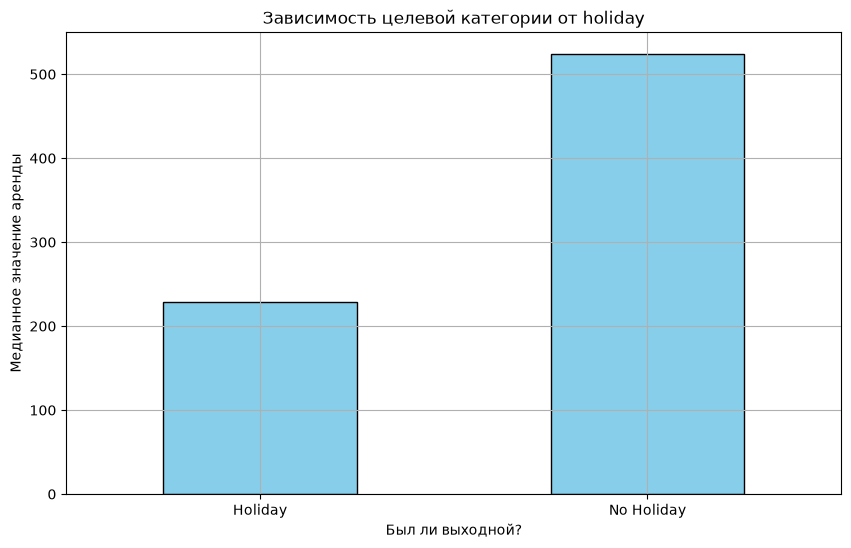

In [43]:
plt.figure(figsize=(10,6))
df_train.groupby('holiday')['rented_bike_count'].median().plot(kind='bar',
                                                                            color='skyblue',
                                                                            edgecolor='black',
                                                                            rot=0)
plt.grid()
plt.xlabel('Был ли выходной?')
plt.ylabel('Медианное значение аренды')
plt.title('Зависимость целевой категории от holiday')

На диаграмме можно увидеть что в выходные дни обычно кол-во арендованных велосипедов не выше, чем в будние.

#### Зависимость спроса от сезона

Посмотрим на зависимость количества арендованных велосипедов от сезона:

Text(0.5, 1.0, 'Зависимость целевой категории от seasons')

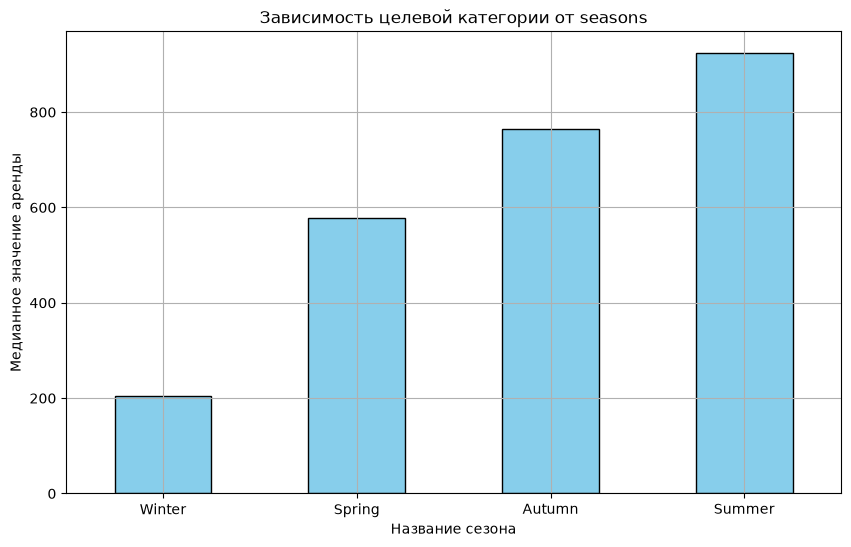

In [44]:
plt.figure(figsize=(10,6))
df_train.groupby('seasons')['rented_bike_count'].median().sort_values().plot(kind='bar',
                                                                            color='skyblue',
                                                                            edgecolor='black',
                                                                            rot=0)
plt.grid()
plt.xlabel('Название сезона')
plt.ylabel('Медианное значение аренды')
plt.title('Зависимость целевой категории от seasons')

Больше всего велосипедов арендуют летом, мньше всего - зимой.

#### Зависимость спроса от числовых признаков

Напишем функцию для построй постройки графиков:

In [45]:
def num_and_target_scatter(col, n_dots):
    plt.figure(figsize=(10,6))
    df_train.plot(kind='scatter',
                 x=col,
                 y='rented_bike_count',
                 s=n_dots,
                 color='skyblue',
                 alpha=0.7,
                 edgecolor='black')
    plt.grid()
    plt.xlabel(f'Значение {col}')
    plt.ylabel(f'Значение rented_bike_count')
    plt.title(f'Зависимость целевой переменной от {col}')

<Figure size 1000x600 with 0 Axes>

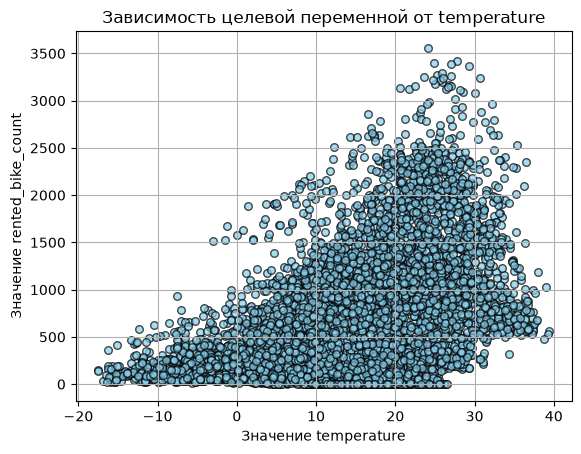

<Figure size 1000x600 with 0 Axes>

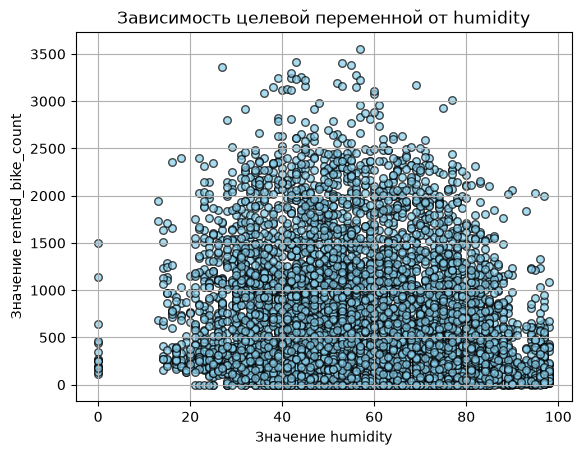

<Figure size 1000x600 with 0 Axes>

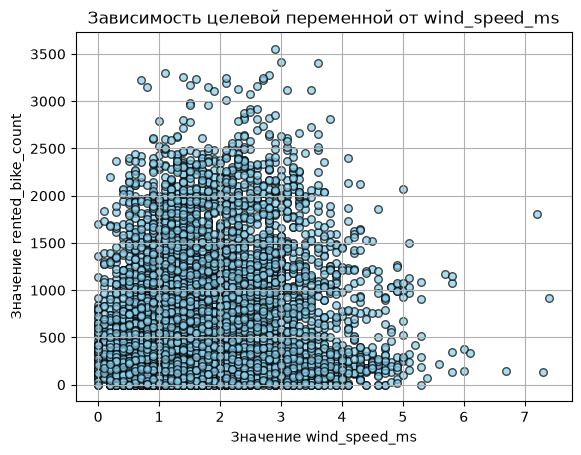

<Figure size 1000x600 with 0 Axes>

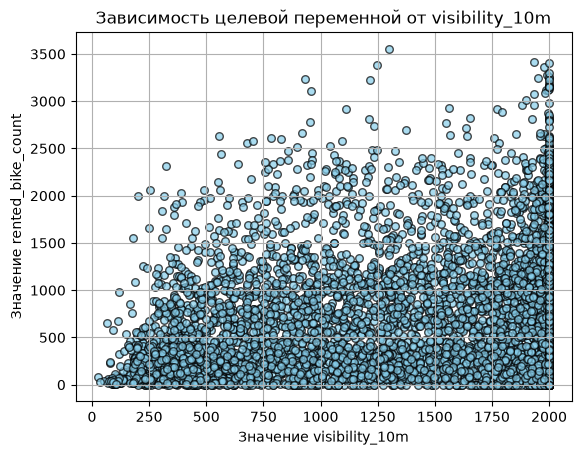

<Figure size 1000x600 with 0 Axes>

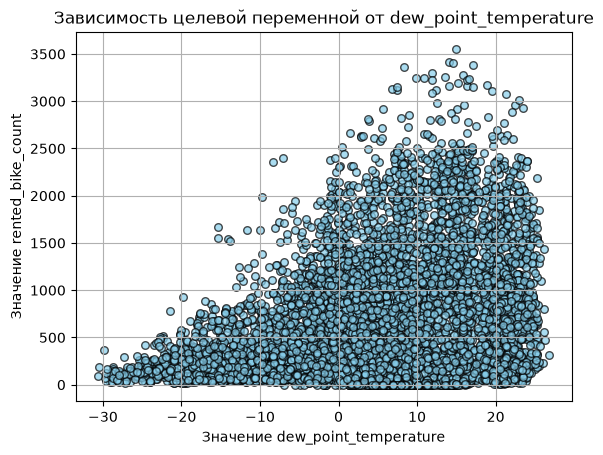

<Figure size 1000x600 with 0 Axes>

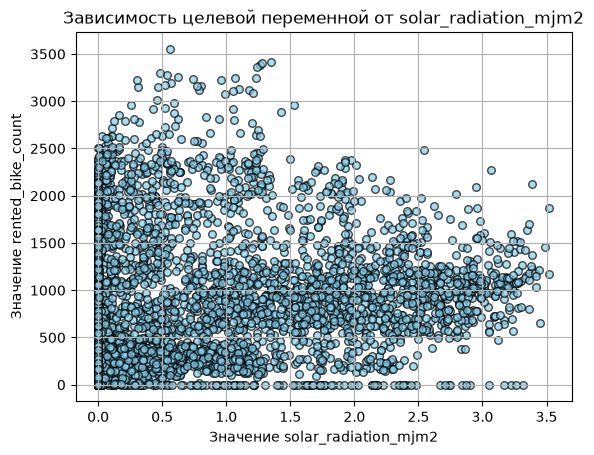

<Figure size 1000x600 with 0 Axes>

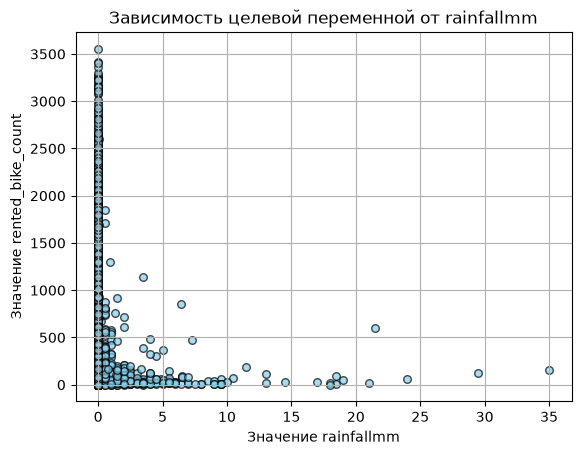

<Figure size 1000x600 with 0 Axes>

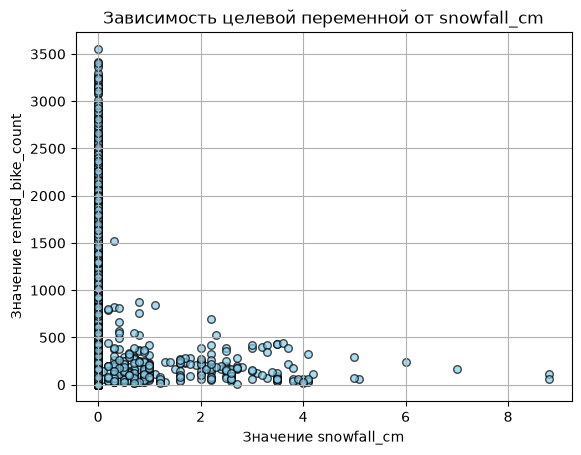

In [46]:
for i in num_cols:
    num_and_target_scatter(i, 30)

- Визуально сиществует связь целевой переменной от температуры. Например: При температуре -10 редко арендуют более 500 велосипедов, а при температуре 30 и выше - редко арендуют менее 500 велосипедов.
- При скорости ветра более 5 м/с спрос падает
- Видимость влияет на спрос только до 5 км. До этого значения спрос на байки меньше, чем при остальных случаев. Большое сколпления точек возле значения 20км вероятнее всего образовалось из-за максимального порога измерения видимости
- Распределение точек в признаке, который отражает точку росы, примерно такое же как и в  случае с температурой. Подоздреваю мультиколлинеарность между этими двумя признаками.
- В признаках, отражающих кол-во осадков и снега основное кол-во точек укладывается возле 0

### Создание новых признаков

##### Бинарный признак наличия осадков

У нас есть исходные признаки `rainfallmm` и `snowfall_cm`. Создадим бинарные признаки которые показывают идет ли дождь/лежит ли снег:

Описание признака is_rain

Кол-во пропусков в столбце is_rain: 0
Доля пропусков в столбце is_rain: 0.0



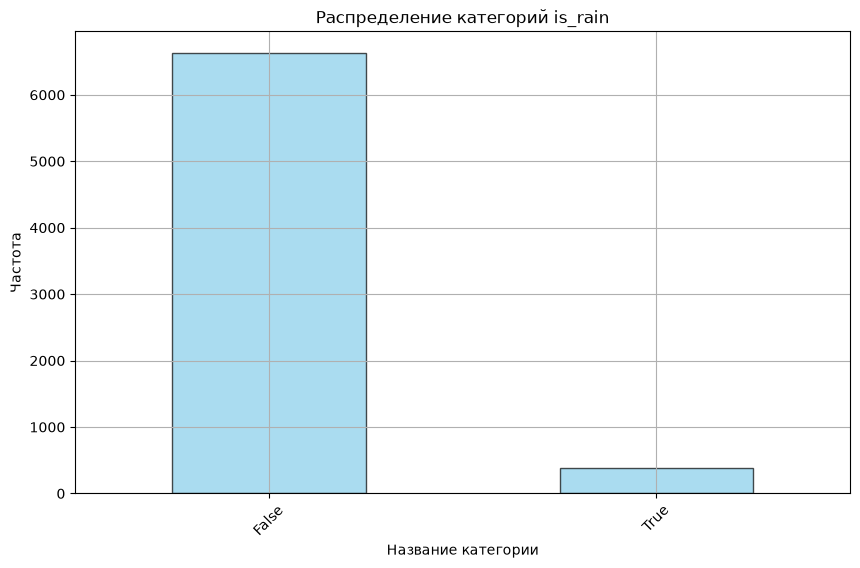

In [47]:
df_train['is_rain'] = df_train['rainfallmm'].apply(lambda x: True if x > 0 else False)
df_train['is_snow'] = df_train['snowfall_cm'].apply(lambda x: True if x > 0 else False)

cat_col_describe('is_rain')

Описание признака is_snow

Кол-во пропусков в столбце is_snow: 0
Доля пропусков в столбце is_snow: 0.0



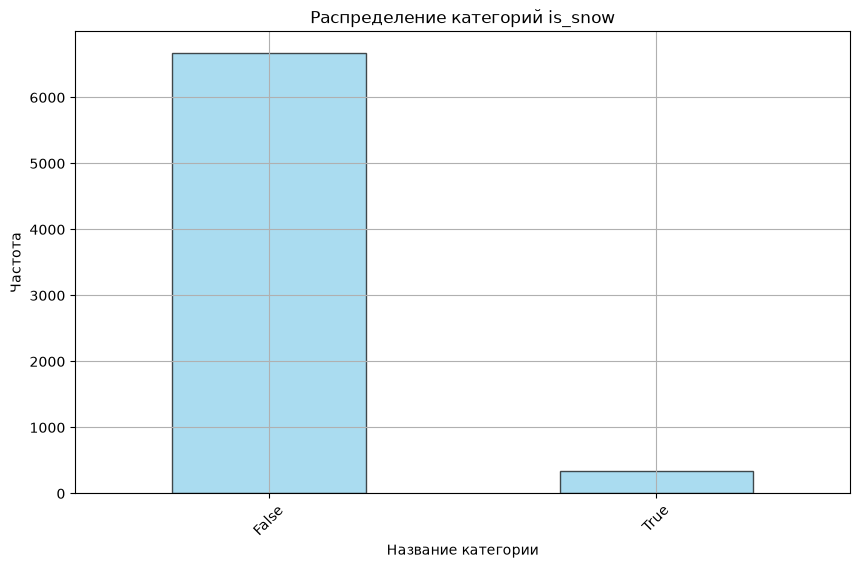

In [48]:
cat_col_describe('is_snow')

Добавим эти признаки к Test выборке:

In [49]:
df_test['is_rain'] = df_test['rainfallmm'].apply(lambda x: True if x > 0 else False)
df_test['is_snow'] = df_test['snowfall_cm'].apply(lambda x: True if x > 0 else False)

#### Бинарный признак комфортной температуры

Если посмотреть на дигарграмму размаха признака `temperature` в EDA, то можно заметить что пик количества аренд происходит при температуре от 20 до 30 градусов. Добавим признак `t_comfort` который отражает эту особенность в виде True или False

In [50]:
df_train['t_comfort'] = df_train['temperature'].apply(lambda x: True if (x >= 20 and x <= 30) else False)
df_test['t_comfort'] = df_test['temperature'].apply(lambda x: True if (x >= 20 and x <= 30) else False)

Описание признака t_comfort

Кол-во пропусков в столбце t_comfort: 0
Доля пропусков в столбце t_comfort: 0.0



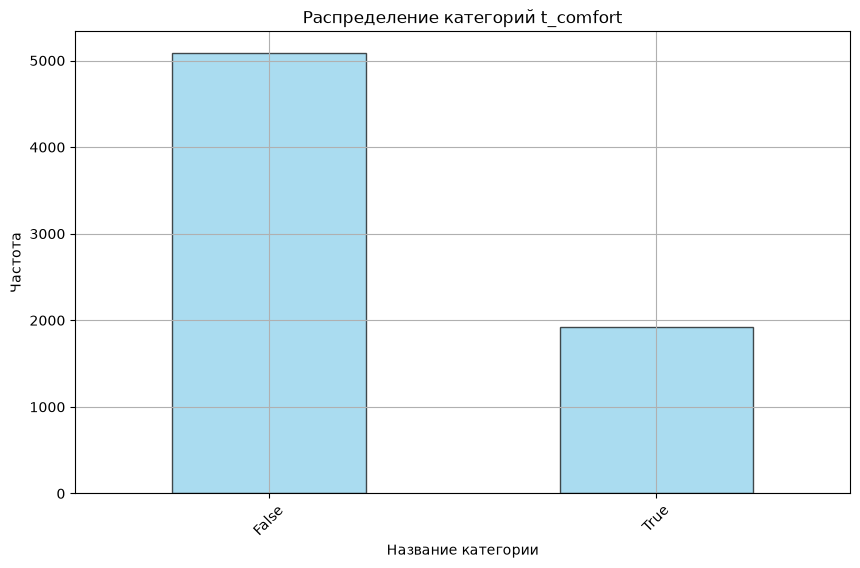

In [51]:
cat_col_describe('t_comfort')

#### Бинарный признак комфортной влажности воздуха

По аналогии с temperature создаем признак `dew_point_comfort`, который отражает комфортную точку росы (в пределах от 10 до 20)

In [52]:
df_train['dew_point_comfort'] = df_train['dew_point_temperature'].apply(lambda x: True if (x >= 10 and x <= 20) else False)
df_test['dew_point_comfort'] = df_test['dew_point_temperature'].apply(lambda x: True if (x >= 10 and x <= 20) else False)

Описание признака dew_point_comfort

Кол-во пропусков в столбце dew_point_comfort: 0
Доля пропусков в столбце dew_point_comfort: 0.0



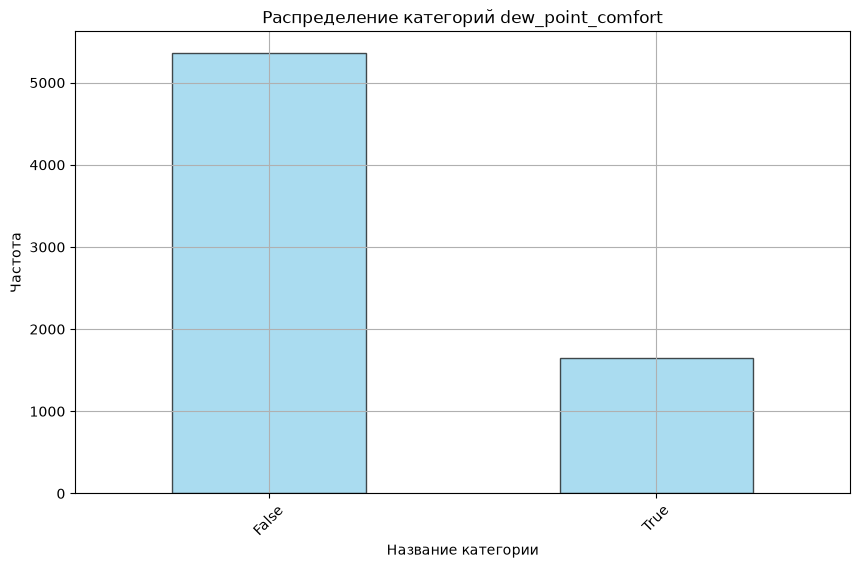

In [53]:
cat_col_describe('dew_point_comfort')

#### Разница температуры и точки росы

Создадим  числовой признак, который показывает насколько воздух близок к насыщению водяным паром и началу конденсации. Для этого нам нужна разница температуры воздуха и точки росы

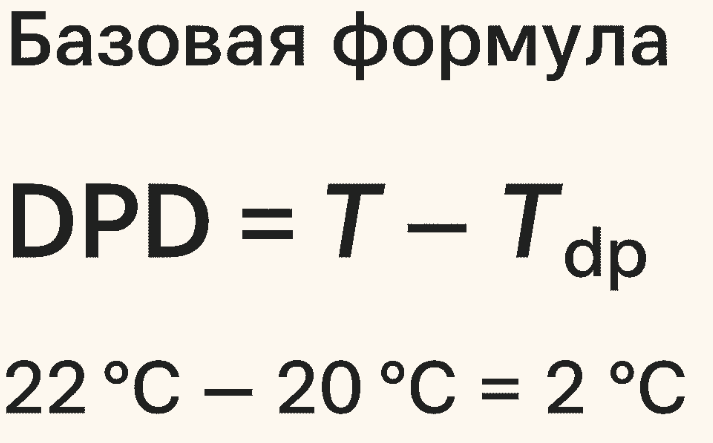

In [54]:
df_train['t_dew_point_diff'] = df_train['temperature'] - df_train['dew_point_temperature']
df_test['t_dew_point_diff'] = df_test['temperature'] - df_test['dew_point_temperature']

Сводка по столбцу t_dew_point_diff



count    7008.000000
mean        8.791424
std         5.304866
min         0.400000
25%         4.600000
50%         8.200000
75%        12.300000
max        31.900000
Name: t_dew_point_diff, dtype: float64


Кол-во пропусков в столбце t_dew_point_diff: 0
Доля пропусков в столбце t_dew_point_diff: 0.0


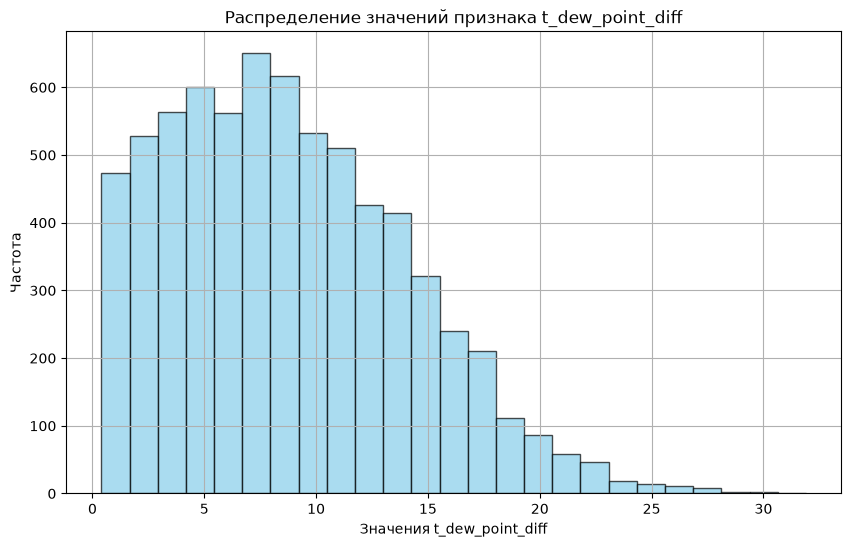

In [55]:
num_col_describe('t_dew_point_diff', 25)

### Построение матрицы корреляций:

Построим матрицу корреляций, используя коэффициент phi k:

interval columns not set, guessing: ['temperature', 'humidity', 'wind_speed_ms', 'visibility_10m', 'dew_point_temperature', 'solar_radiation_mjm2', 'rainfallmm', 'snowfall_cm', 'rented_bike_count', 't_dew_point_diff']


<Axes: >

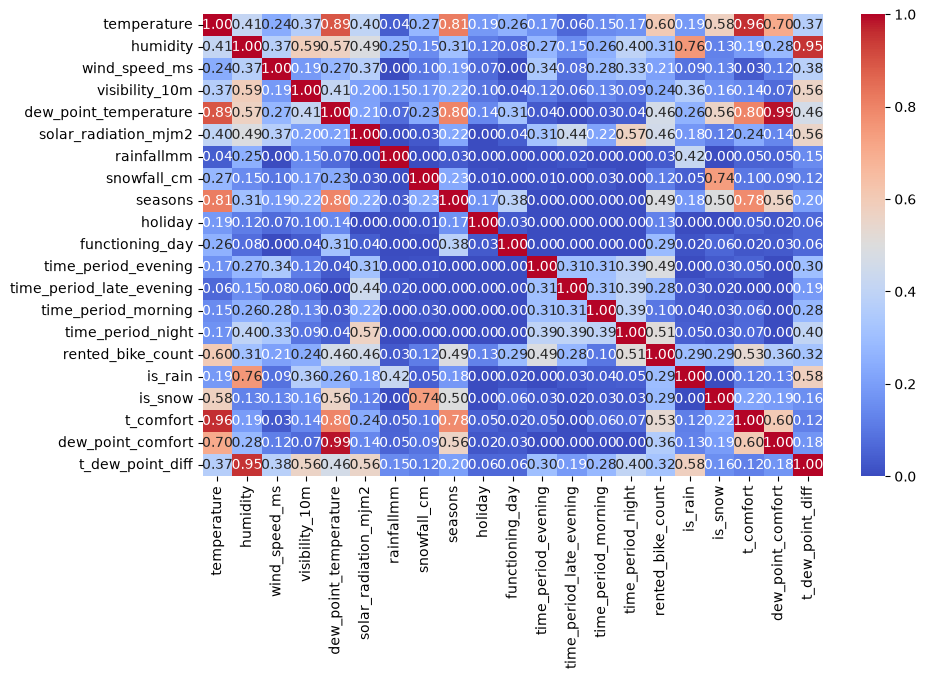

In [56]:
corr_matrix = df_train.phik_matrix()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,
           annot=True,
           cmap='coolwarm', 
           fmt='.2f',)

По матрице признаков видно что большинство признаков так или иначе коррелируют с целевой переменной. Наименьший коэфициент корреляций показывает rainfallmm 

### Вывод по EDA

В рамках исследовательского анализа данных была проведена следующая работа:
- Датасеты проверены на наличие дубликатов
- Изучены числовые и категориальные признаки в рамках распределения, а так же в разрезе целевой переменной
- На основе имеющихся признаков созданы признаки `is_rain`, `is_snow`, `t_comfort`, `dew_point_comfort`, `t_dew_point_diff`
- Построена матрица корреляций 

## Разработка baseline нелинейных моделей

### Обучение при стандартных гиперпараметрах

Разбиваем данные на train и val выборки:

In [57]:
X_train_val = df_train.drop(columns='rented_bike_count')
y_train_val = df_train['rented_bike_count']

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, shuffle=True, random_state=RANDOM_STATE)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [58]:
num_sts_cols = ['temperature', 'humidity', 'wind_speed_ms', 'visibility_10m', 'dew_point_temperature', 'solar_radiation_mjm2',
           'rainfallmm', 'snowfall_cm', 't_dew_point_diff']
oh_cols = ['seasons', 'holiday', 'functioning_day', ]
time_period_cols = ['time_period_evening', 'time_period_late_evening', 'time_period_morning', 'time_period_night', 'is_rain', 'is_snow', 't_comfort',
                   'dew_point_comfort']

Создадим два препроцессора. Один с масштабированием для kNN, и второй без масштабирования для DecisionTree

In [59]:
# kNN preprocessor
knn_nums_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
knn_oh_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder())
])

knn_preprocessor = ColumnTransformer([
    ('nums', knn_nums_pipeline, num_sts_cols),
    ('onehot', knn_oh_pipeline, oh_cols),
    ('time_period_imputer', 'passthrough', time_period_cols)
])

In [60]:
# DecisionTree preprocessor
tree_nums_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

tree_oh_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder())
])

tree_preprocessor = ColumnTransformer([
    ('nums', tree_nums_pipeline, num_sts_cols),
    ('onehot', tree_oh_pipeline, oh_cols),
    ('time_period_imputer', 'passthrough', time_period_cols)
])

Создадим простые модели kNN и DecisionTree и посмотрим на метрики при кросс-валидации.

In [61]:
scoring = {
    'rmse':'neg_root_mean_squared_error',
    'mae':'neg_mean_absolute_error',
    'r2':'r2'
}

In [62]:
# Baseline kNN
baseline_knn = KNeighborsRegressor(n_neighbors=5, metric='euclidean', weights='uniform')

baseline_knn_pipeline = Pipeline([
    ('preprocessor', knn_preprocessor),
    ('model', baseline_knn)
])

cv_knn_score = cross_validate(
    baseline_knn_pipeline,
    X_train, y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print('Результаты baseline kNN:')
print('')
print(f'RMSE: {-cv_knn_score["test_rmse"].mean()}')
print(f'MAE: {-cv_knn_score["test_mae"].mean()}')
print(f'R2: {cv_knn_score["test_r2"].mean()}')

Результаты baseline kNN:

RMSE: 321.12188389975887
MAE: 213.51687594807532
R2: 0.7515859049051039


Видим, что результаты kNN без подбора гиперпараметров уже лучше, чем исходная линейная модель.

Обучим baseline DecisionTree:

In [63]:
baseline_tree = DecisionTreeRegressor(random_state=RANDOM_STATE)

baseline_tree_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', baseline_tree)
])

cv_tree_score = cross_validate(
    baseline_tree_pipeline,
    X_train, y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print('Результаты baseline DecisionTree:')
print('')
print(f'RMSE: {-cv_tree_score["test_rmse"].mean()}')
print(f'MAE: {-cv_tree_score["test_mae"].mean()}')
print(f'R2: {cv_tree_score["test_r2"].mean()}')

Результаты baseline DecisionTree:

RMSE: 397.1668909431472
MAE: 248.70557025277404
R2: 0.6199948909236118


Результаты дерева решений до подбора гиперпараметров так же лучше, чем у базовой линейной модели.

### Подбор гиперпараметров

Используем otuna для подбора оптимальных гиперпараметров наших новых моделей:

Сначала обучим kNN:

In [64]:
def knn_objective(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 1, 100),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan'])
    }

    model = KNeighborsRegressor(**params)
    pipeline = Pipeline([
        ('preprocessor', knn_preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    )
    return -scores.mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
knn_study = optuna.create_study(direction='minimize', sampler=sampler)

knn_study.optimize(knn_objective, n_trials=150, show_progress_bar=True)

print(knn_study.best_value)

[I 2026-10-02 02:55:00,540] A new study created in memory with name: no-name-6ef48b4c-06b2-4633-bfae-90e6a0bb87a0


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-10-02 02:55:02,196] Trial 0 finished with value: 337.4422547361668 and parameters: {'n_neighbors': 38, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 337.4422547361668.
[I 2026-10-02 02:55:02,481] Trial 1 finished with value: 304.71100499038664 and parameters: {'n_neighbors': 16, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 1 with value: 304.71100499038664.
[I 2026-10-02 02:55:02,639] Trial 2 finished with value: 330.755267260636 and parameters: {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 1 with value: 304.71100499038664.
[I 2026-10-02 02:55:02,818] Trial 3 finished with value: 315.0578027088421 and parameters: {'n_neighbors': 19, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 1 with value: 304.71100499038664.
[I 2026-10-02 02:55:03,156] Trial 4 finished with value: 327.1651988355554 and parameters: {'n_neighbors': 62, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 1 with v

Лучший результат по целевой метрике RMSE: 303.08

Подбираем гиперпараметры для DecisionTree:

In [65]:
def tree_objective(trial):
    params = {
        'max_depth':trial.suggest_int('max_depth', 1, 60),
        'min_samples_split':trial.suggest_int('min_samples_split', 2, 100),
        'min_samples_leaf':trial.suggest_int('min_samples_leaf', 2, 100),
        'max_leaf_nodes':trial.suggest_int('max_leaf_nodes', 2, 300),
        'ccp_alpha':trial.suggest_float('ccp_alpha', 0.0001, 0.1)
    }

    model = DecisionTreeRegressor(random_state=RANDOM_STATE, **params)
    pipeline = Pipeline([
        ('preprocessor', tree_preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    )
    return -scores.mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
tree_study = optuna.create_study(direction='minimize', sampler=sampler)

tree_study.optimize(tree_objective, n_trials=350, show_progress_bar=True)

print(tree_study.best_value)

[I 2026-10-02 02:55:48,323] A new study created in memory with name: no-name-c5db3aaf-2382-41ac-9e26-2907f1cef6d7


  0%|          | 0/350 [00:00<?, ?it/s]

[I 2026-10-02 02:55:48,566] Trial 0 finished with value: 354.3726120293751 and parameters: {'max_depth': 23, 'min_samples_split': 96, 'min_samples_leaf': 74, 'max_leaf_nodes': 180, 'ccp_alpha': 0.01568626218019941}. Best is trial 0 with value: 354.3726120293751.
[I 2026-10-02 02:55:48,713] Trial 1 finished with value: 360.20476005366254 and parameters: {'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 87, 'max_leaf_nodes': 181, 'ccp_alpha': 0.07083645052182495}. Best is trial 0 with value: 354.3726120293751.
[I 2026-10-02 02:55:48,825] Trial 2 finished with value: 510.42314979598615 and parameters: {'max_depth': 2, 'min_samples_split': 98, 'min_samples_leaf': 84, 'max_leaf_nodes': 65, 'ccp_alpha': 0.01826431422398935}. Best is trial 0 with value: 354.3726120293751.
[I 2026-10-02 02:55:48,982] Trial 3 finished with value: 344.49347792918877 and parameters: {'max_depth': 12, 'min_samples_split': 32, 'min_samples_leaf': 53, 'max_leaf_nodes': 131, 'ccp_alpha': 0.029193791105784

Соберем табличку с результатами работы модели на Test выборке:

In [66]:
X_test = df_test.drop(columns='rented_bike_count')
y_test = df_test['rented_bike_count']

knn_final_pipeline = Pipeline([
    ('preprocessor', knn_preprocessor),
    ('model', KNeighborsRegressor(**knn_study.best_params))
])
tree_final_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', DecisionTreeRegressor(**tree_study.best_params))
])

knn_final_pipeline.fit(X_train_val, y_train_val)
tree_final_pipeline.fit(X_train_val, y_train_val)

y_pred_knn_final = knn_final_pipeline.predict(X_test)
y_pred_tree_final = tree_final_pipeline.predict(X_test)

test_results = pd.DataFrame({
    'Model': ['Baseline', 'kNN', 'DecisionTree'],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_test_pred_baseline)),
            np.sqrt(mean_squared_error(y_test, y_pred_knn_final)),
            np.sqrt(mean_squared_error(y_test, y_pred_tree_final))],
    'MAE': [mean_absolute_error(y_test, y_test_pred_baseline),
           mean_absolute_error(y_test, y_pred_knn_final),
           mean_absolute_error(y_test, y_pred_tree_final)],
    'R2': [r2_score(y_test, y_test_pred_baseline),
          r2_score(y_test, y_pred_knn_final),
          r2_score(y_test, y_pred_tree_final)]
})

print('Результаты всех моделей на test выборке:')

display(test_results)


Результаты всех моделей на test выборке:


,Model,RMSE,MAE,R2
0,Baseline,411.454458,312.531298,0.586293
1,kNN,305.407477,206.460321,0.772066
2,DecisionTree,309.768451,207.737264,0.765510


Исходя из полученных метрик можем сказать что лучше всего в данной задаче показывает себя модель kNN. У неё ниже целевая переменная RMSE (305.4), а так же она описывает большее количество данных (R2 = 0.77). Схожее значение RMSE на тренировочной и тестовой выборках говорит об отсутсвии переобучения. В качестве финальной модели будет выбрана модель kNN.

Посмотрим на важностьпризнаков для модели. Т.к. у kNN нет встроенной функции для оценки - важность признаков будем оценивать на дереве, т.к. показатели дерева близки к kNN

In [67]:
feature_names = tree_final_pipeline[:-1].get_feature_names_out()
top_features = pd.DataFrame({
    'Feature_name': feature_names,
    'Coefs': tree_final_pipeline.named_steps['model'].feature_importances_
})

top_features.sort_values('Coefs', ascending=False).head(10)

,Feature_name,Coefs
0,nums__temperature,0.337763
20,time_period_imputer__time_period_night,0.174154
8,nums__t_dew_point_diff,0.116640
16,onehot__functioning_day_Yes,0.107710
17,time_period_imputer__time_period_evening,0.086939
18,time_period_imputer__time_period_late_evening,0.046376
12,onehot__seasons_Winter,0.035066
5,nums__solar_radiation_mjm2,0.031191
23,time_period_imputer__t_comfort,0.014123
21,time_period_imputer__is_rain,0.011575


Наибольшее влияение на модель оказывает температура воздуха, время суток, разница температуры и точки росы, сезон, а так же работает ли прокат.

## Отчет о проделанной работе

В рамках проделанной работы была улучшена линейная модель предсказания количества арендованных велосипедов для компании BikeSouth. 
- Успешно загруженны данные, предоставленные заказчиком
- Софрмирован список библиотек, необходимы для работы над проектом. Все необходимые инструменты сохранены в `requirements.txt`
- Изучена baseline линейная модель, предоставленная заказчиком для улучшения
- Проведен исследовательский анализ данных. Иследована матрица признаков, а так же целевая переменная. Подобрана стратегия заполнения пропусков. Датасеты проверены на дубликаты. Построена матрица корреляций.
-  Разработаны пайпалны для моделей kNN и DecisionTree. Проведено обучение на стандартных гиперпараметрах, а так же последующий подбор гиперпараметров.
-  В результате обучения финанальной моделью выбрана модель kNN, имеющая RMSE 305 против 411 исходной линейной модели. Модель демонстрирует значительное увеличение точности прогнозирования.
- Выявлены топ признаков по важности

Модель kNN рекомендуется к внедрению

## Сохранение модели

In [68]:
# Сохранение финальной модели
try:
    joblib.dump(knn_final_pipeline, 'models/upgraded_knn_model.joblib')
except:
    joblib.dump(knn_final_pipeline, 'upgraded_knn_model.joblib')

In [69]:
# Проверка загрузки модели
try:
    loaded_pipeline = joblib.load('upgraded_knn_model.joblib')
except:
    loaded_pipeline = joblib.load('models/upgraded_knn_model.joblib')
X_test_sample = X_test.head(5)
loaded_predictions = loaded_pipeline.predict(X_test_sample)
pipeline_prediction = knn_final_pipeline.predict(X_test_sample)
print(loaded_predictions)
print(pipeline_prediction)

[ 316.86826288  180.86868722  302.9098232  1239.23107247 1240.17025032]
[ 316.86826288  180.86868722  302.9098232  1239.23107247 1240.17025032]


Данные совпадают, модель загружена успешно.